# Cell 1: Load data and inspect structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the B3DB classification dataset
df = pd.read_csv('../data/B3DB_classification.tsv', sep='\t')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (7807, 12)
Columns: ['NO.', 'compound_name', 'IUPAC_name', 'SMILES', 'CID', 'logBB', 'BBB+/BBB-', 'Inchi', 'threshold', 'reference', 'group', 'comments']


,NO.,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,group,comments
0,1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,A,NaN
1,2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,A,NaN
2,3,clioquinol,5-chloro-7-iodoquinolin-8-ol,Oc1c(I)cc(Cl)c2cccnc12,2788.0,-2.40,BBB-,InChI=1S/C9H5ClINO/c10-6-4-7(11)9(13)8-5(6)2-1...,NaN,R18|R26|R27|,A,NaN
3,4,bbcpd11 (cimetidine analog) (y-g13),2-[2-[(3-bromopyridin-2-yl)methylsulfanyl]ethy...,CCNC(=NCCSCc1ncccc1Br)NC#N,14022517.0,-2.15,BBB-,InChI=1S/C12H16BrN5S/c1-2-15-12(18-9-14)17-6-7...,NaN,R2|R2|R8|R40|R2|R2|R2|R2|R18|R21|R25|R25|R26|R...,A,NaN
4,5,schembl614298,"(2s,3s,4s,5r)-6-[[(4r,4ar,7s,7ar,12bs)-7-hydro...",CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...,18595497.0,-2.15,BBB-,InChI=1S/C23H27NO9/c1-24-7-6-23-10-3-4-12(25)2...,NaN,R25|,A,NaN


# Cell 2: Check class distribution

Class distribution:
BBB+/BBB-
BBB+    4956
BBB-    2851
Name: count, dtype: int64


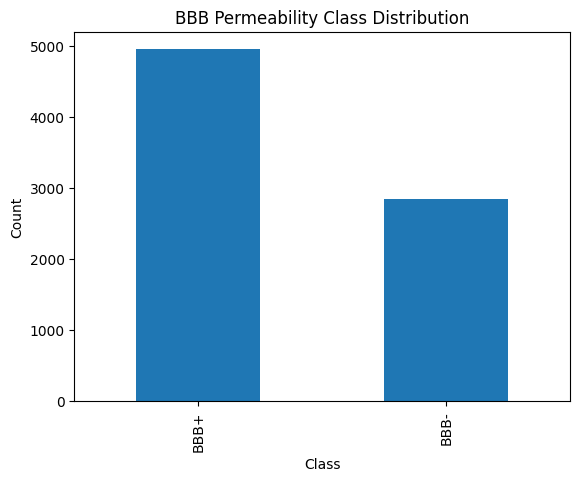

In [2]:
# Count BBB+ vs BBB- samples
print("Class distribution:")
print(df['BBB+/BBB-'].value_counts())

# Visualize
df['BBB+/BBB-'].value_counts().plot(kind='bar')
plt.title('BBB Permeability Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Cell 3：Check logBB (continuous target)

Non-null logBB count: 1058

logBB summary statistics:
count    1058.000000
mean       -0.077873
std         0.751623
min        -2.690000
25%        -0.535000
50%        -0.020000
75%         0.420000
max         1.700000
Name: logBB, dtype: float64


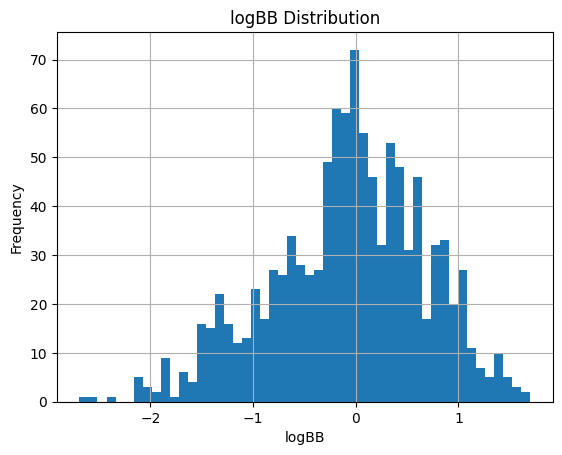

In [3]:
# How many molecules have a logBB value
print(f"Non-null logBB count: {df['logBB'].notna().sum()}")
print(f"\nlogBB summary statistics:")
print(df['logBB'].describe())

# Histogram
df['logBB'].hist(bins=50)
plt.title('logBB Distribution')
plt.xlabel('logBB')
plt.ylabel('Frequency')
plt.show()

# Cell 4: Inspect SMILES and draw a molecule

First 5 SMILES strings:
0     O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O
1    COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...
2                               Oc1c(I)cc(Cl)c2cccnc12
3                           CCNC(=NCCSCc1ncccc1Br)NC#N
4    CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...
Name: SMILES, dtype: str


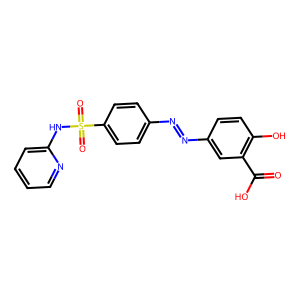

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# Show first 5 SMILES
print("First 5 SMILES strings:")
print(df['SMILES'].head())

# Render the first molecule
mol = Chem.MolFromSmiles(df['SMILES'].iloc[0])
Draw.MolToImage(mol, size=(300, 300))